# 2026年9月11日 2026機械学習PJ 第2回 深層学習の概要 説明ノートブック

本ノートブックでは，以下の内容を知る／触れることを目的とする:

1. 前回扱った機械学習と深層学習は，どのようにつながっているのか
2. ニューラルネットワークは，入力されたデータをどのように処理するのか
3. PyTorchでは，モデルの学習をどのように実装するのか
4. ミニバッチ，Epoch，損失関数，誤差逆伝播などの学習テクニックは，実装上どこに現れるのか
5. 訓練データと評価データを見ながら，学習が進んでいるか，過学習していないかをどう判断するのか
6. 深層学習を使えば，常に従来の機械学習より高精度になるのか

取り組む皆さんに注意してほしいこと:

- 今回も，数式を厳密に導出することより，**モデル構築の流れとコードの対応関係**を理解することを重視します．
- モデルを見るときは，まず**入力と出力が何か**を意識すること．また，**情報をベクトルや行列という数値で表現する**という感覚に少しでも馴染むこと．
- コードを一字一句暗記する必要はありません．PyTorchにも便利な機能が多数用意されているので，**何をしたいときに，どの処理を呼び出しているのか**を意識してください．
- 深層学習は非常に広い分野です．今回は全結合ニューラルネットワークを使った2値分類だけを扱い，CNNやTransformerなどは最後に少し紹介します．
- 今回はKaggleで有名なTitanicデータセットを用いて，乗客が生存したかどうかを予測します．

作成者: 坪井 一馬 (本資料は生成AIを使用して作成した部分がありますが，最終的な責任は坪井に帰属します)

## 0. 【重要】 説明

実装がよくわからなくても，この部分は理解してほしいです．

### 0.1. モデル構築の流れ

前回は，機械学習モデルを構築する基本的な流れとして，①データの準備，②モデルの準備，③学習，④テスト・推論という4段階を扱いましたが，深層学習でもこのような流れは変わりません．

ロジスティック回帰では `model.fit(X_train, y_train)` とするだけで学習できました．しかし，この`fit()`の内部では概念的に，以下の処理が繰り返されています．
1. 現在のモデルで予測する
2. 予測と正解のずれを損失として計算する
3. 損失を小さくするための修正を計算する
4. モデル内部のパラメータを更新する

今回PyTorchを用いて実装する深層学習では，この部分をより明示的に記述します．

### 0.2. 深層学習とは何か

深層学習は，機械学習手法の一種です．そして，ニューラルネットワークは深層学習を行うモデルの基本的な仕組みのことです．

ニューラルネットワークは，生物の神経系から着想を得た数理モデルであり，**一般には**そうでない手法に比べて高い精度でタスクを解くことができるので広く用いられています．ただし，現在のニューラルネットワークは，人間の脳そのものの忠実な再現とは言えません(というか人間の脳に関する解析が必要)．

深層学習では，ニューラルネットワークの中に**複数の「層」を用意**し，それを経て，入力されたデータを段階的に別の**数値表現**へ変換していきます．ここで得られる中間の数値表現を，**潜在表現**や**埋め込み(表現)**，**内部表現**と呼ぶことがあります．

例えば「入力された特徴量 → 中間層 → 潜在表現 → さらに別の中間層 → 分類に役立つ潜在表現 → 出力」という順序で処理が行われます．こういう処理の内容や順序を，そのモデルの**構造**(**アーキテクチャ**)といい，モデルの精度に大きく影響します．ただし，アーキテクチャの設計において，どう設計すればうまくいくかという「定理」や「法則」のようなものはありません．経験則として「こういうアーキテクチャが良い」というのはあるので，それを参考にする場合が多いです．

### 0.3. 深層学習では「特徴も全部自動で作られる」のか

「従来の機械学習では人間が特徴を決め，深層学習では特徴も全部自動で学習する」と説明されることがあります．これは深層学習の特徴を捉えた説明ではありますが，少し単純化されているともいえます．

今回例として扱うTitanicデータセットでは，以下のようなカラムがあります．これらは人間が決めたものです．
- 年齢
- 性別
- 客室クラス
- 運賃
- 同乗していた家族の人数

深層学習の特に重要な点は，**与えられた入力から，問題を解くために「役立つ」はずの潜在表現を複数の層を通して学習したり扱えること**です．その部分は自動で行われます．画像や文章のように，元の入力が非常に高次元で複雑になるほど，この表現学習の価値が大きくなります．

### 0.4. 今回の学習コードで最も重要な5行

今回の最後には，少なくとも次の5行が何をしているかわかるようになっていると良いと思います．
1. `optimizer.zero_grad()`：前回までに保存されている勾配(損失関数を更新するためのもの)をリセットする．
2. `outputs = model(features)`：現在のモデルへ入力を与えて，予測値であるlogitを得る．
3. `loss = loss_function(outputs, labels)`：損失関数に基づいて，予測と正解のずれを損失として計算する．
4. `loss.backward()`：損失を小さくするために，各パラメータをどちらへどの程度動かせばよいかを勾配として計算する．
5. `optimizer.step()`：計算された勾配を用いて，実際にモデルのパラメータを更新する．

なお，今回は**PyTorch**と呼ばれる深層学習ライブラリを使用します．場合によってはTensorFlowという別のライブラリが使われることもありますが，汎用性等の観点からここでは使用しません．TensorFlowとPyTorchとでは，学習速度が違うだけでなく，実装や利用可能な環境等が異なりますので注意してください．

## 使用するライブラリの読み込み

今回も，scikit-learnを前処理や比較用モデルのために利用し，深層学習の実装にはPyTorchを用います．

⭐️**重要**⭐️ **最初にGoogle Colabの設定において「T4 GPU」を使用する設定にしてください．画面右上にある「▼」から選択できます．**

In [47]:
# Python標準ライブラリ
from pathlib import Path
import copy
import random

# 数値計算・表形式データ・可視化
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [48]:
# 実行ごとのばらつきを小さくするため，乱数を固定する
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# GPUが使える場合はGPU，使えない場合はCPUを使用する
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("使用するデバイス:", device)

使用するデバイス: cuda


## 1. データの準備

今回はKaggleと呼ばれるデータサイエンスコンペティションでよく使われる「Titanicデータセット」を題材とします．

Titanic(タイタニック)は映画で有名ですが，沈没した船で，その船にいた乗客それぞれの特性(性別や名前，客室名など)と，その乗客が生存したか否かが記録されています．

ここでの目的は「乗客それぞれの特性」を説明変数，その乗客の「生存/死亡」を目的変数としてモデルを構築することです．つまり，「乗客それぞれの特性」から「生存したか否か」を2値分類で予測しようとします．

### 1.1. データセットの読み込みとEDA

まず，データセットを読み込みます．

In [49]:
TITANIC_URL = (
    "https://raw.githubusercontent.com/"
    "datasciencedojo/datasets/master/titanic.csv"
)

# ColabなどではURLから読み込む．
try:
    df = pd.read_csv(TITANIC_URL)
    print("Titanicデータをオンラインから読み込みました．")
except Exception:
    local_candidates = [
        Path("titanic.csv"),
        Path("/mnt/data/titanic.csv"),
    ]

    for local_path in local_candidates:
        if local_path.exists():
            df = pd.read_csv(local_path)
            print(
                "Titanicデータをローカルファイルから読み込みました:",
                local_path,
            )
            break
    else:
        raise FileNotFoundError(
            "Titanicデータを取得できませんでした．"
            "titanic.csvをNotebookと同じフォルダに置いてください．"
        )

print("データ数:", len(df))
print("列数:", len(df.columns))

display(df.head())

Titanicデータをオンラインから読み込みました．
データ数: 891
列数: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


いきなりニューラルネットワークへ入力するのではなく，まずデータの内容を確認する**探索的データ分析**(EDA)を行います．以下の観点でデータを確認しましょう．
- どのような列があるか
- 欠損値はあるか
- 正解ラベルの比率はどうなっているか
- 各特徴量と正解との間にどのような傾向があるか

In [50]:
print("各列のデータ型:")
display(df.dtypes)

print("\n列ごとの欠損値数:")
display(
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\n生存者・死亡者の人数:")
display(
    df["Survived"]
    .value_counts()
    .sort_index()
)

各列のデータ型:


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64



列ごとの欠損値数:


,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0



生存者・死亡者の人数:


,count
Survived,
0,549
1,342


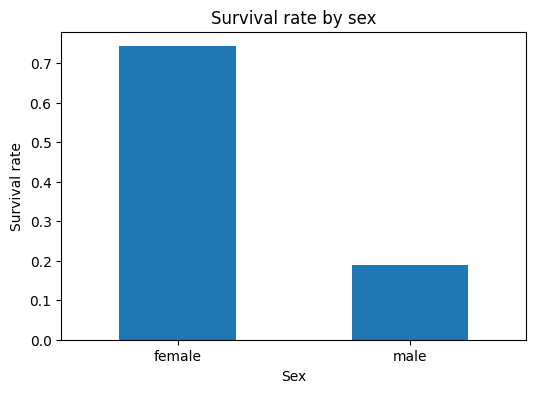

In [51]:
# 性別ごとの生存率を可視化する
survival_by_sex = (
    df.groupby("Sex")["Survived"]
    .mean()
)

survival_by_sex.plot(
    kind="bar",
    figsize=(6, 4),
)

plt.ylabel("Survival rate")
plt.title("Survival rate by sex")
plt.xticks(rotation=0)
plt.show()

**［確認1］**

上のグラフから，性別と生存率の間にはどのような傾向が見られるか，自分の言葉で説明してみてください．

ここで見つかった傾向が，そのまま「原因」を意味するわけではないことにも注意してください．

[**模範解答例**] 明らかに女性の生存率が高く，男性の生存率が低いことがわかる(ただし，全体に占める男性，女性の割合には注意が必要であり，男性であれば死亡している可能性が高いと結論づけて良いわけではない)．

### 1.2. 入力`X`と正解`y`を用意して3分割する

説明変数として数多くのものが存在しますが，今回は次の説明変数を使ってみましょう．

| 説明変数 | 内容 |
|---|---|
| `Pclass` | 客室クラス |
| `Sex` | 性別 |
| `Age` | 年齢 |
| `SibSp` | 同乗している兄弟・配偶者数 |
| `Parch` | 同乗している親・子どもの数 |
| `Fare` | 運賃 |
| `Embarked` | 乗船港 |

`Name`や`Ticket`などにも情報は含まれていますが，今回は深層学習の基本的な実装を理解することを優先して扱いません．

In [52]:
# 今回使用する特徴量
feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
]

X = df[feature_columns].copy()
y = df["Survived"].copy()

# 全体を訓練60%と一時データ40%へ分割する
(
    X_train,
    X_temp,
    y_train,
    y_temp,
) = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y,
)

# 一時データ40%を，評価20%とテスト20%へ分割する
(
    X_val,
    X_test,
    y_val,
    y_test,
) = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("訓練データ:", X_train.shape)
print("評価データ:", X_val.shape)
print("テストデータ:", X_test.shape)

訓練データ: (534, 7)
評価データ: (178, 7)
テストデータ: (179, 7)


### 1.3. 前処理

ここで，`Age`など数値のデータを量的データ，`Sex`など文字列で入っている(あるいは数値であるがその値の大きさに意味はない)ようなデータを質的データ(カテゴリカルデータ)といいます．

現在の入力データにおいて，量的データと質的データが混在していたり，以下の問題があります．
- 量的データ: `Age`などの一部カラムにある欠損値，値の規模が全く異なる数値が同じテーブル内に混在
- 質的データ: `Sex`や`Embarked`などのカラムに含まれる文字列

これらを処理しないままモデルに入力すると，そもそも学習ができなかったり，学習できたように見えても精度が非常に悪くなります．そこで，以下のような前処理を行います．
1. 数値: 欠損値を中央値で補間し，統計的に標準化
2. 文字列: 欠損値を最頻値で補間し，ワンホットエンコーディングを行う

ここでは，評価データやテストデータの情報を訓練時に使わないことが重要です．そのため，**前処理の基準も訓練データだけから考えます**．

#### 補足: ワンホットエンコーディング

ワンホットエンコーディングとは，元々文字列で入っているものを，**そうであるか否かを表す0,1(バイナリ)の数値でカラムに入れる**ことです．

`Sex`や`Embarked`のように，カラム内の各要素に文字列で入っているようなデータをそのままニューラルネットワークへ入力できません．例えば，`Sex`(性別)には`male, female`があります．

そこで，カテゴリごとに新しい列を用意し，**該当するカテゴリだけを1，それ以外を0として表します**．

| Sex | male | female |
| --- | --- | --- |
| male | 1 | 0 |
| female | 0 | 1 |

In [53]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
]

# 数値特徴量は欠損値を中央値で補完し，標準化する
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
])

# scikit-learnのバージョン差を吸収する
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False,
    )

# カテゴリ特徴量は欠損値を最頻値で補完し，One-Hot Encodingする
categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent"),
    ),
    (
        "onehot",
        one_hot_encoder,
    ),
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features,
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features,
    ),
])

# 前処理の基準は訓練データだけから学習する
X_train_processed = preprocessor.fit_transform(
    X_train
).astype(np.float32)

# 評価・テストデータには，同じ変換を適用するだけにする
X_val_processed = preprocessor.transform(
    X_val
).astype(np.float32)

X_test_processed = preprocessor.transform(
    X_test
).astype(np.float32)

processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print("前処理後の特徴量数:", len(processed_feature_names))
print("訓練データ:", X_train_processed.shape)
print("評価データ:", X_val_processed.shape)
print("テストデータ:", X_test_processed.shape)

前処理後の特徴量数: 12
訓練データ: (534, 12)
評価データ: (178, 12)
テストデータ: (179, 12)


元の入力は7列でしたが，One-Hot Encodingによって入力される数値の個数は増えています．

これは新しい情報が勝手に増えたのではなく，例えば，

```text
Sex = male
Sex = female
```

のような質的データを，機械学習で扱うことのできる0と1の数値へ変換したためです．

In [54]:
print("前処理後の特徴量名:")

for name in processed_feature_names:
    print(name)

前処理後の特徴量名:
numeric__Age
numeric__SibSp
numeric__Parch
numeric__Fare
categorical__Pclass_1
categorical__Pclass_2
categorical__Pclass_3
categorical__Sex_female
categorical__Sex_male
categorical__Embarked_C
categorical__Embarked_Q
categorical__Embarked_S


### 1.4. Tensor，Dataset，DataLoader

PyTorchでは，データを`Tensor`と呼ばれる形式で扱います．

さらに，深層学習では訓練データを「ミニバッチ」と呼ばれる小さいまとまりに分けて学習することが一般的です．その「ミニバッチ」に含まれるデータ数を「バッチサイズ」といい，後述のハイパーパラメータになりますので，学習前に指定する必要があります．

```text
訓練データ全体
├─ ミニバッチ1 → パラメータ更新
├─ ミニバッチ2 → パラメータ更新
├─ ミニバッチ3 → パラメータ更新
└─ ...
```

用語を整理すると，今回の場合では

- **Sample**：乗客1人分のデータ
- **Mini-batch**：一度にモデルへ入力する複数人分のデータ
- **1 Epoch**：訓練データ全体を1周して学習すること

となります．

PyTorchでは，

- `TensorDataset`：入力と正解を1組にする
- `DataLoader`：Datasetからミニバッチを取り出す

ために使います．

In [55]:
# NumPy配列をTensorへ変換し，Datasetを作る
train_dataset = TensorDataset(
    torch.tensor(
        X_train_processed,
        dtype=torch.float32,
    ),
    torch.tensor(
        y_train.to_numpy(),
        dtype=torch.float32,
    ).reshape(-1, 1),
)

val_dataset = TensorDataset(
    torch.tensor(
        X_val_processed,
        dtype=torch.float32,
    ),
    torch.tensor(
        y_val.to_numpy(),
        dtype=torch.float32,
    ).reshape(-1, 1),
)

test_dataset = TensorDataset(
    torch.tensor(
        X_test_processed,
        dtype=torch.float32,
    ),
    torch.tensor(
        y_test.to_numpy(),
        dtype=torch.float32,
    ).reshape(-1, 1),
)

# DataLoaderでミニバッチ単位に取り出せるようにする
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
)

print("訓練データのミニバッチ数:", len(train_loader))

訓練データのミニバッチ数: 17


例えば`batch_size=32`なら，原則として32人分のデータをまとめて予測し，その結果から1回パラメータを更新します．

前回扱ったscikit-learnの`LogisticRegression`と違って，今回のPyTorchではこの更新の単位がコード上にはっきり見えます．

In [56]:
# 実際にミニバッチを1つだけ取り出して形を確認する
X_batch_example, y_batch_example = next(
    iter(train_loader)
)

print("入力ミニバッチ:", X_batch_example.shape)
print("正解ミニバッチ:", y_batch_example.shape)

入力ミニバッチ: torch.Size([32, 12])
正解ミニバッチ: torch.Size([32, 1])


## 2. モデルの準備

### 2.1. ニューラルネットワークをクラスとして定義する

PyTorchでは，`nn.Module`を継承したクラスとしてモデルを定義します．自分で難しい数式を用意する必要はありません．

Pythonのクラスに慣れていない場合は，以下のようなイメージで良いです．
1. `class TitanicNet`: モデルの設計図の用意
2. `model = TitanicNet()`: モデルの設計図に基づいて，実際のモデルを作る

クラス内では，以下の2つが重要です．
- `__init__`: 使用する層を準備する
- `forward`: 入力が層を通る順序を定義する

#### モデル構造

今回のモデルは次の構造です．
1. 前処理後の入力
2. Linear: 32次元の潜在表現へ
3. 活性化関数 ReLU
4. Dropout
5. Linear: 16次元の潜在表現へ
6. 活性化関数 ReLU
7. Linear: 1次元の数値(スカラー)へ

各パーツについて説明します．
- `Linear`は，入力された高次元の数値を，重みとバイアスを用いた線形な演算で別次元の数値へ変換します．ここで扱われる数値としてはなかなか実感が湧かないかもしれませんが，**情報を表現する数値**としてぼんやりと捉えておくくらいで構いません．
    - この**重みとバイアスを調整して，最終的な出力が正しくなるようにする**のが学習です．
- `ReLU`は活性化関数と呼ばれるもので，内部で出た「負の値」を0にし，正の値をそのまま通します．
    - Linearだけを何層重ねても，全体として線形な変換にまとめられてしまうため，**複雑な関係を捕捉できるようにする**という目的で，ReLUのような非線形変換を途中に入れることが重要です．
- `Dropout`は，学習中だけモデル内の重みの一部をランダムに0にすることで，特定の重みだけに頼りすぎて出力されることを抑えます．

In [57]:
class TitanicNet(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim_1=32,
        hidden_dim_2=16,
        dropout_rate=0.1,
    ):
        super().__init__()

        self.network = nn.Sequential(
            # 入力を32次元の潜在表現へ変換する
            nn.Linear(
                input_dim,
                hidden_dim_1,
            ),
            nn.ReLU(),

            # 学習中だけ一部の重みの値をランダムに0にする
            nn.Dropout(dropout_rate),

            # 32次元の潜在表現を16次元へ変換する
            nn.Linear(
                hidden_dim_1,
                hidden_dim_2,
            ),
            nn.ReLU(),

            # 最後に生存側への傾きを表す1次元の数値(スカラー)を出力する
            nn.Linear(
                hidden_dim_2,
                1,
            ),
        )

    def forward(self, x):
        return self.network(x)

In [58]:
INPUT_DIM = X_train_processed.shape[1]

model = TitanicNet(
    input_dim=INPUT_DIM,
    hidden_dim_1=32,
    hidden_dim_2=16,
    dropout_rate=0.1,
).to(device)

print(model)

TitanicNet(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)


### 2.2. 出力が1個なのはなぜか

今回は，死亡(0)，生存(1)の2値分類です．そのため，最後のlinear層で「生存する側へどの程度傾いているか」を表すスコアをスカラーとして出力します．このスコアを**logit**(ロジット)と呼びます．

logitはそのままでは確率ではありません．そこでSigmoid関数と呼ばれるものを適用して，範囲が0以上1以下の確率にします．そして，明確なしきい値を決めることで，確率が0.5を超えていれば生存，そうでなければ死亡などと予測できます．

以下のセルについて，まだ学習していないので，この時点の重みやバイアスは初期値です．したがって，出力される確率に意味のある判断根拠はまだありません．

In [59]:
model.eval()

with torch.no_grad():
    example_logits = model(
        X_batch_example.to(device)
    )

    example_probabilities = torch.sigmoid(
        example_logits
    )

print("学習前のlogit:")
print(
    example_logits[:5]
    .cpu()
    .numpy()
    .reshape(-1)
)

print("\n学習前の生存確率:")
print(
    example_probabilities[:5]
    .cpu()
    .numpy()
    .reshape(-1)
)

学習前のlogit:
[-0.03822595 -0.03688893 -0.05143792 -0.05757961 -0.05597864]

学習前の生存確率:
[0.4904447  0.49077883 0.4871433  0.48560905 0.48600897]


### 2.3. パラメータとハイパーパラメータ

深層学習では，「パラメータ」と「ハイパーパラメータ」を区別することが重要です．
- **パラメータ**: 学習によってモデル自身が更新する値です．例えば，各層の重みやバイアスです．繰り返しますが，**このパラメータを更新することで，最終的に演算を経て正しい予測を出せるようにします**．
- **ハイパーパラメータ**(ハイパラ): 人間が学習前に決める学習設定の値です．モデルの精度に非常に大きく影響します．例えば，学習時の設定値です．詳細は説明しませんが，学習率やバッチサイズ，中間層のユニット数，学習エポック数，ドロップアウト率などがあります．

In [60]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("学習可能なパラメータ数:", total_parameters)

print("\n最初のLinear層の重みの形:")
print(model.network[0].weight.shape)

学習可能なパラメータ数: 961

最初のLinear層の重みの形:
torch.Size([32, 12])


## 3. 学習

### 3.1. 損失関数

学習では，モデルの予測と正解がどの程度ずれているかを数値で表します．この値を**損失 Loss**と呼び，損失を計算する関数を**損失関数 Loss Function**と呼びます．

前回のIrisは3クラス分類だったため`CrossEntropyLoss`を使いました．今回は2値分類なので，`BCEWithLogitsLoss`を使います．

この損失関数は，以下の処理をまとめて行います．

1. モデルが出したlogit
2. 内部でSigmoid関数を適用
3. 生存確率
4. 正解0／1とのずれをBinary Cross Entropyで計算

そのため，学習時にはモデルの最後に自分でSigmoidを置くとか，関数を具体的に実装する必要はありません．

### 3.2. Optimizer

損失を計算しただけでは，モデルの性能は変わりませんので，**損失が小さくなる方向へ，モデルのパラメータを実際に更新する**必要があります(これこそが学習)．

そのためにOptimizerと呼ばれるパーツを使います．色々な種類がありますが，今回は`Adam`を使います．

今回のOptimizerには**学習率**(Learning Rate)を設定します．学習率は，1回の更新でパラメータをどの程度動かすかに関係する重要なハイパーパラメータです．値の大きさによって，以下のような弊害があるので，うまく設定するのが重要です．
- 小さすぎる: 学習が進まない
- 大きすぎる: 最適な値の周辺を飛び越えて，学習が不安定になることがある

ただしこれは非常に簡易的な実装であり，実際はもっと高度な設定を入れて，学習がうまくいくようにすることが多いです．その高度な設定についてはここでは説明しませんが，Kaggleに取り組む上では教えます．

In [61]:
loss_function = nn.BCEWithLogitsLoss()

LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

### 3.3. 1ミニバッチだけ使って，学習の5ステップを見る

いきなり長い学習ループを見る前に，別の小さなモデルを使って，1ミニバッチだけ学習してみます．

特に，`loss.backward()` は「重みを更新する命令」ではなく，各パラメータをどちらへどの程度動かせば損失が小さくなるかを計算しています．実際にパラメータを更新するのは`optimizer.step()`です．

以下のコードを実行するとわかるように，1回のミニバッチ処理だけでも，モデル内部の重みが実際に変化しています．改めてですが，深層学習の「学習」とは，訓練データそのものをモデル内部へ保存することではなく，**入力から正しい出力を得るための多数のパラメータを更新すること**です．

In [62]:
# 学習の仕組みを確認するための別モデルを作る
demo_model = TitanicNet(
    input_dim=INPUT_DIM,
).to(device)

demo_loss_function = nn.BCEWithLogitsLoss()

demo_optimizer = torch.optim.Adam(
    demo_model.parameters(),
    lr=0.001,
)

demo_X = X_batch_example.to(device)
demo_y = y_batch_example.to(device)

# 更新前の重みを保存しておく
weight_before = (
    demo_model.network[0]
    .weight
    .detach()
    .clone()
)

# 1. 前回の勾配をリセットする
demo_optimizer.zero_grad()

# 2. 現在のモデルで予測する
demo_outputs = demo_model(demo_X)

# 3. 予測と正解のずれを計算する
demo_loss = demo_loss_function(
    demo_outputs,
    demo_y,
)

# 4. 損失を小さくするための修正方向を計算する
demo_loss.backward()

print("Loss:", demo_loss.item())
print(
    "勾配の一部:",
    demo_model.network[0]
    .weight.grad[0, :5],
)

# 5. 実際にパラメータを更新する
demo_optimizer.step()

weight_after = (
    demo_model.network[0]
    .weight
    .detach()
    .clone()
)

print(
    "1回の更新による重み変化の平均:",
    torch.mean(
        torch.abs(
            weight_after - weight_before
        )
    ).item(),
)

Loss: 0.6780243515968323
勾配の一部: tensor([-0.0024,  0.0028,  0.0020,  0.0021,  0.0006], device='cuda:0')
1回の更新による重み変化の平均: 0.0008984165033325553


### 3.4. 評価用の関数を用意する

評価データでは，モデルを学習させずに性能だけを確認します．

そのため，以下の設定を行います．
- `model.eval()`：評価モードへ切り替える
- `torch.no_grad()`：勾配計算を行わない

今回のモデルには，モデル構造内の一部の層のニューロンをオフにして学習対象としないDropoutが入っています．この影響を評価時には無効にする必要があり，`model.train()`と`model.eval()`の切り替えには実際に意味があります．

In [63]:
def evaluate_model(
    model,
    data_loader,
    loss_function,
    device,
    threshold=0.5,
):
    # 評価モードへ切り替える
    model.eval()

    total_loss = 0.0
    total_count = 0

    probabilities_all = []
    predictions_all = []
    labels_all = []

    # 評価時には勾配を計算しない
    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.to(device)

            logits = model(features)

            loss = loss_function(
                logits,
                labels,
            )

            probabilities = torch.sigmoid(
                logits
            )

            predictions = (
                probabilities >= threshold
            ).float()

            total_loss += (
                loss.item()
                * features.size(0)
            )

            total_count += features.size(0)

            probabilities_all.extend(
                probabilities
                .cpu()
                .numpy()
                .reshape(-1)
            )

            predictions_all.extend(
                predictions
                .cpu()
                .numpy()
                .reshape(-1)
            )

            labels_all.extend(
                labels
                .cpu()
                .numpy()
                .reshape(-1)
            )

    return {
        "loss": total_loss / total_count,
        "accuracy": accuracy_score(
            labels_all,
            predictions_all,
        ),
        "probabilities": np.array(
            probabilities_all
        ),
        "predictions": np.array(
            predictions_all
        ).astype(int),
        "labels": np.array(
            labels_all
        ).astype(int),
    }

### 3.5. 複数Epochにわたって学習する

ここから，訓練データを何周も繰り返して学習します．この繰り返しの1単位をエポック(Epoch)といいます．

評価データに対するLossが最も小さかった時点のモデルを保存しておき，最終的に用いることが重要です．これは，最後のEpochで学習させすぎている状態の場合，最良とは限らないためです．

In [64]:
MAX_EPOCHS = 80

train_loss_history = []
train_accuracy_history = []

val_loss_history = []
val_accuracy_history = []

best_val_loss = float("inf")
best_epoch = None
best_model_state = None

for epoch in range(MAX_EPOCHS):
    # ------------------------------
    # 訓練
    # ------------------------------
    model.train()

    running_loss = 0.0
    train_count = 0

    train_predictions = []
    train_labels = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # 1. 前回の勾配をリセットする
        optimizer.zero_grad()

        # 2. 現在のモデルで予測する
        logits = model(X_batch)

        # 3. 正解とのずれを計算する
        loss = loss_function(
            logits,
            y_batch,
        )

        # 4. 修正方向を計算する
        loss.backward()

        # 5. パラメータを更新する
        optimizer.step()

        running_loss += (
            loss.item()
            * X_batch.size(0)
        )

        train_count += X_batch.size(0)

        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        train_predictions.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
            .reshape(-1)
        )

        train_labels.extend(
            y_batch
            .detach()
            .cpu()
            .numpy()
            .reshape(-1)
        )

    train_loss = (
        running_loss / train_count
    )

    train_accuracy = accuracy_score(
        train_labels,
        train_predictions,
    )

    # ------------------------------
    # 評価
    # ------------------------------
    val_result = evaluate_model(
        model,
        val_loader,
        loss_function,
        device,
    )

    train_loss_history.append(
        train_loss
    )

    train_accuracy_history.append(
        train_accuracy
    )

    val_loss_history.append(
        val_result["loss"]
    )

    val_accuracy_history.append(
        val_result["accuracy"]
    )

    # 評価Lossが改善したときだけモデルを保存する
    if val_result["loss"] < best_val_loss:
        best_val_loss = val_result["loss"]
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
    ):
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Loss {train_loss:.4f} | "
            f"Val Loss {val_result['loss']:.4f} | "
            f"Train Acc {train_accuracy:.3f} | "
            f"Val Acc {val_result['accuracy']:.3f}"
        )

print()
print("評価Lossが最小だったEpoch:", best_epoch)
print(f"最小の評価Loss: {best_val_loss:.4f}")

Epoch   1 | Train Loss 0.6739 | Val Loss 0.6587 | Train Acc 0.680 | Val Acc 0.691
Epoch  10 | Train Loss 0.4515 | Val Loss 0.4251 | Train Acc 0.807 | Val Acc 0.831
Epoch  20 | Train Loss 0.4124 | Val Loss 0.3938 | Train Acc 0.818 | Val Acc 0.854
Epoch  30 | Train Loss 0.4083 | Val Loss 0.3920 | Train Acc 0.839 | Val Acc 0.843
Epoch  40 | Train Loss 0.3798 | Val Loss 0.3923 | Train Acc 0.835 | Val Acc 0.831
Epoch  50 | Train Loss 0.3851 | Val Loss 0.3984 | Train Acc 0.843 | Val Acc 0.826
Epoch  60 | Train Loss 0.3799 | Val Loss 0.4005 | Train Acc 0.839 | Val Acc 0.826
Epoch  70 | Train Loss 0.3693 | Val Loss 0.4069 | Train Acc 0.846 | Val Acc 0.831
Epoch  80 | Train Loss 0.3751 | Val Loss 0.4139 | Train Acc 0.846 | Val Acc 0.831

評価Lossが最小だったEpoch: 31
最小の評価Loss: 0.3899


### 3.6. 学習曲線を確認する

Epochが増えるにつれて，訓練データと評価データに対する性能がどのように変化したかを可視化した曲線，つまり損失関数で計算された損失を図示したものを学習曲線と呼びます．

特に，以下の観点確認します．
- 訓練Lossは下がっているか
- 評価Lossも下がっているか
- 訓練精度と評価精度が大きく離れていないか

#### 過学習

訓練lossが下がっているのに評価lossが上がっている場合，訓練データに対して**過学習**(overfitting)しているといいます．

これは，訓練データに対して正しい予測は出せるようになっているが，そこにない評価データに対しては正しくない予測を出しているという状態です．一般論として，見た事のないデータに対してどのくらい正確に予測ができるかが重要であり，過学習が起きてしまうと，モデルの学習自体が適切になされていないと判断されます．

過学習が起きているかを検知して早期に学習を止める**早期打ち切り**(early stopping)も重要ですが，そういったことはここでは実装しません．

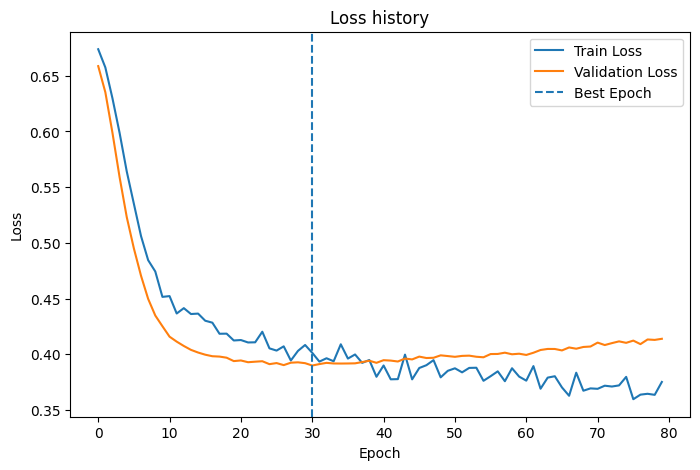

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_loss_history,
    label="Train Loss",
)

plt.plot(
    val_loss_history,
    label="Validation Loss",
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label="Best Epoch",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss history")
plt.legend()
plt.show()

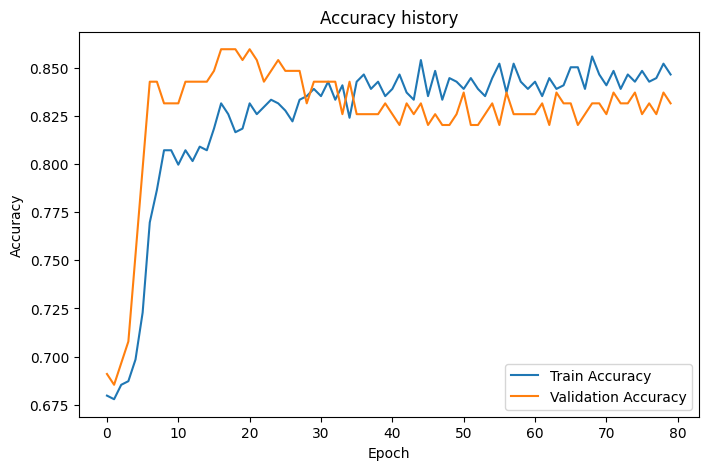

In [71]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracy_history,
    label="Train Accuracy",
)

plt.plot(
    val_accuracy_history,
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy history")
plt.legend()
plt.show()

## 4. テスト・推論

### 4.1. 最良モデルを復元して，テストデータを評価する

評価データに基づいてモデルを選んだので，その時点のモデルを復元します．そして，ここで初めてテストデータを用いて最終性能を確認します．

In [72]:
model.load_state_dict(
    best_model_state
)

test_result = evaluate_model(
    model,
    test_loader,
    loss_function,
    device,
)

print(
    f"Neural NetworkのテストLoss: "
    f"{test_result['loss']:.4f}"
)

print(
    f"Neural NetworkのテストAccuracy: "
    f"{test_result['accuracy']:.3f}"
)

Neural NetworkのテストLoss: 0.4144
Neural NetworkのテストAccuracy: 0.838


### 4.2. 評価指標

2値分類では，単に正しく予測できたかだけでなく，以下の評価指標があります．以下の指標のうちで**どれを重視するかは，その時の状況によります**．生存者を正しく予測できているかであればRecall(再現率)が大事で，とにかく生存の可能性を拾えているかであればPrecisionが大事です．

- Accuracy(正解率): 生存(1)，死亡(0)を正しく予測できた割合．
- Precision(適合率): **生存(1)と予測したうち**で，本当に生存(1)の割合．
- Recall(再現率): **実際に生存(1)であったデータのうち**で，それを正しく生存(1)と予測した割合．
- F1-score: PrecisionとRecallの調和平均
- 混同行列(confusion matrix): 予測結果の解釈4パターンを行列にしたもの

Precision: 0.885
Recall:    0.667
F1-score:  0.760


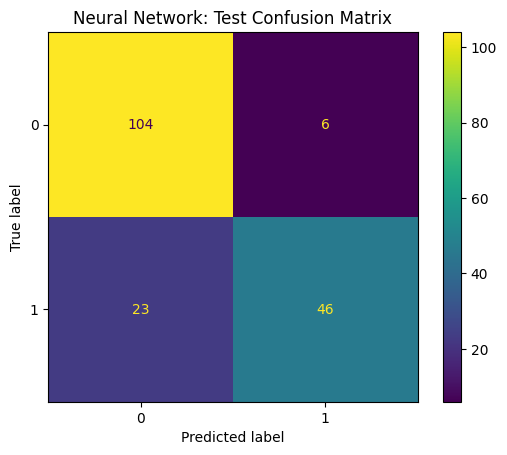

In [73]:
test_precision = precision_score(
    test_result["labels"],
    test_result["predictions"],
)

test_recall = recall_score(
    test_result["labels"],
    test_result["predictions"],
)

test_f1 = f1_score(
    test_result["labels"],
    test_result["predictions"],
)

print(f"Precision: {test_precision:.3f}")
print(f"Recall:    {test_recall:.3f}")
print(f"F1-score:  {test_f1:.3f}")

test_cm = confusion_matrix(
    test_result["labels"],
    test_result["predictions"],
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=[
        "0",
        "1",
    ],
)

display_cm.plot()
plt.title("Neural Network: Test Confusion Matrix")
plt.show()

### 4.3. 1人の乗客を推論する

最後に，テストデータから1人を取り出して，生存確率を確認します．

In [74]:
SAMPLE_INDEX = 0

sample_X = torch.tensor(
    X_test_processed[SAMPLE_INDEX],
    dtype=torch.float32,
).unsqueeze(0).to(device)

sample_true_label = int(
    y_test.iloc[SAMPLE_INDEX]
)

model.eval()

with torch.no_grad():
    sample_logit = model(
        sample_X
    )

    sample_probability = torch.sigmoid(
        sample_logit
    ).item()

sample_prediction = int(
    sample_probability >= 0.5
)

print(
    "正解:",
    "生存" if sample_true_label == 1
    else "死亡",
)

print(
    "予測:",
    "生存" if sample_prediction == 1
    else "死亡",
)

print(
    f"生存確率: "
    f"{sample_probability:.3f}"
)

正解: 生存
予測: 生存
生存確率: 0.928


## 5. ロジスティック回帰と比較する

深層学習を使ったからといって，必ず高精度になるとは限りません．比較のため，同じ前処理済みのデータにロジスティック回帰を適用します．

,Model,Test Accuracy
0,Logistic Regression,0.804469
1,Neural Network,0.837989


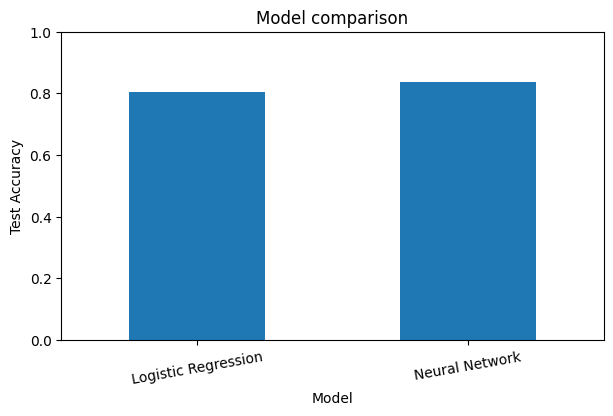

In [75]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
)

logistic_model.fit(
    X_train_processed,
    y_train,
)

logistic_test_predictions = (
    logistic_model.predict(
        X_test_processed
    )
)

logistic_test_accuracy = accuracy_score(
    y_test,
    logistic_test_predictions,
)

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Neural Network",
    ],
    "Test Accuracy": [
        logistic_test_accuracy,
        test_result["accuracy"],
    ],
})

display(comparison_df)

comparison_df.plot(
    x="Model",
    y="Test Accuracy",
    kind="bar",
    legend=False,
    figsize=(7, 4),
)

plt.ylim(0.0, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Model comparison")
plt.xticks(rotation=10)
plt.show()

**［確認2］**

どちらのモデルの精度が高かったでしょうか．

また，今回深層学習の精度が高かったとしても，そこから「深層学習はロジスティック回帰より常に優れている」と結論できるでしょうか．

[**模範解答例**] ニューラルネットワークがわずかに高い精度となった．本タスクにおいて，深層学習はロジスティック回帰よりも常に優れているとは言えず，データ数や学習条件等に依存して変わる可能性がある．

## 6. [補足] 深層学習の使い道

### 深層学習がより役立つ場面

Titanicでは，年齢や性別など，人間が理解しやすい特徴量を入力しました．

一方，画像や音声，動画，文章では，入力自体が非常に複雑です．ただし，例えば画像なら，画素から線や色の変化，部分的な物体の形状，より複雑なパターン，...というように，多層のネットワークを通して内部表現を学習できます．

代表的なモデルとして，以下のようなものがあります．これらは画像だけでなく，音声や動画，文章など様々なメディアに使われます．
- CNN：主に画像処理
- RNN，LSTM：系列データ
- Transformer：文章，画像，音声など
- Diffusion Model：画像生成など
- TransformerベースのLLM：大規模言語モデル

それぞれの構造は大きく異なりますし，内部での数理的な仕組みも難しいものが多いですが，以下の考え方は同じです．
1. 入力
2. 予測
3. 損失
4. 誤差逆伝播
5. パラメータ更新

色々あるモデルのうちで，そのモデルの**入力と出力がどうなっているのか**を把握する，その次に**個性を把握する**(数式ベースでなくて良い)ことが重要です．そうすれば使うことはできます．その先でもっと深入りしたり，それを改造しようとする場合は，ある程度数理的な背景を理解する必要もあります．重要な数学は微分積分，線形代数，確率・統計です．

### 深層学習の発展の背景

深層学習が急速に発展した背景として，少なくとも次の3点があります．

1. **大量のデータ**: Web，画像，動画，文章など，大量のデジタルデータを扱えるようになりました．

2. **GPUなどの計算資源**: ニューラルネットワークで頻繁に現れる大量の行列計算を，高速に並列で実行できるようになりました．

3. **学習技術の改善**: ReLU，正規化，Optimizer，残差結合(Residual Connection)など，多層ネットワークを安定して学習するための技術が発展しました．

一方で，以下の課題もあります．
- 学習に大きな計算資源が必要になる場合がある
- 大量のデータが必要になる場合がある
- なぜその判断になったのか解釈しにくい場合がある
- 学習データの偏りも学習する
- 過学習することがある

## まとめ

今回も，モデル構築の流れに戻って整理します．

| モデル構築の段階 | 今回のPyTorchでの実装 |
|---|---|
| (1) データの準備 | 前処理，Tensor，Dataset，DataLoader |
| (2) モデルの準備 | `nn.Module`，`Linear`，`ReLU` |
| (3) 学習 | `zero_grad` → `model` → `loss` → `backward` → `step` |
| (3) 学習中の評価 | `model.eval()`，`torch.no_grad()` |
| (4) テスト・推論 | Sigmoidで確率化し，未知データを分類 |

最も重要なのは，次の5行です．

```python
optimizer.zero_grad()
outputs = model(X_batch)
loss = loss_function(outputs, y_batch)
loss.backward()
optimizer.step()
```

今後，CNNやTransformerなど，より複雑なモデルを扱う場合でも，この基本的な学習の流れは何度も登場します．